# PaperMind — RAG Exploration Notebook

This notebook covers:
1. Chunking experiments — how chunk size affects the number and length of chunks
2. Embedding visualisation — see your chunks plotted in 2D vector space
3. Retrieval quality checks — inspect which chunks come back for test queries
4. Score distribution — visualise similarity scores across many queries

## 0. Setup

In [18]:
import sys
import os
import warnings

# Add project root to path so we can import src modules
sys.path.insert(0, os.path.abspath(".."))

from dotenv import load_dotenv
load_dotenv("../.env")

warnings.filterwarnings("ignore")
print("Setup complete")

Setup complete


## 1. Chunking Experiments

We test 4 different chunk sizes on a real document from our pipeline.
Goal: find a size large enough to contain a complete thought,
but small enough that irrelevant content does not dilute the answer.
Our chosen setting is chunk_size=500, overlap=100 (highlighted in orange).

In [19]:
import fitz
import numpy as np
from langchain.text_splitter import RecursiveCharacterTextSplitter

# Change this to any PDF you have in uploads/
PDF_PATH = "../uploads/GDPR_EN.pdf"

doc = fitz.open(PDF_PATH)
full_text = ""
for page in doc:
    full_text += page.get_text("text")
doc.close()

print(f"Document: {PDF_PATH}")
print(f"Total characters: {len(full_text):,}")
print(f"Preview: {full_text[:200]}")

Document: ../uploads/GDPR_EN.pdf
Total characters: 201,564
Preview: This text is meant purely as a documentation tool and has no legal effect. The Union's institutions do not assume any liability 
for its contents. The authentic versions of the relevant acts, includin


In [20]:
chunk_configs = [
    {"chunk_size": 200,  "chunk_overlap": 50},
    {"chunk_size": 500,  "chunk_overlap": 100},   # our setting
    {"chunk_size": 800,  "chunk_overlap": 150},
    {"chunk_size": 1200, "chunk_overlap": 200},
]

results = []
for config in chunk_configs:
    splitter = RecursiveCharacterTextSplitter(
        chunk_size=config["chunk_size"],
        chunk_overlap=config["chunk_overlap"],
        separators=["\n\n", "\n", ". ", " ", ""],
    )
    chunks  = splitter.split_text(full_text)
    lengths = [len(c) for c in chunks]
    results.append({
        "chunk_size": config["chunk_size"],
        "num_chunks": len(chunks),
        "avg_len":    int(np.mean(lengths)),
        "min_len":    min(lengths),
        "max_len":    max(lengths),
        "chunks":     chunks,
    })
    print(
        f"chunk_size={config['chunk_size']:4d} | "
        f"num_chunks={len(chunks):4d} | "
        f"avg_len={int(np.mean(lengths)):4d} | "
        f"min={min(lengths):3d} | "
        f"max={max(lengths):4d}"
    )

chunk_size= 200 | num_chunks=1296 | avg_len= 161 | min= 22 | max= 199
chunk_size= 500 | num_chunks= 509 | avg_len= 465 | min=319 | max= 498
chunk_size= 800 | num_chunks= 312 | avg_len= 769 | min=726 | max= 799
chunk_size=1200 | num_chunks= 201 | avg_len=1165 | min=1012 | max=1198


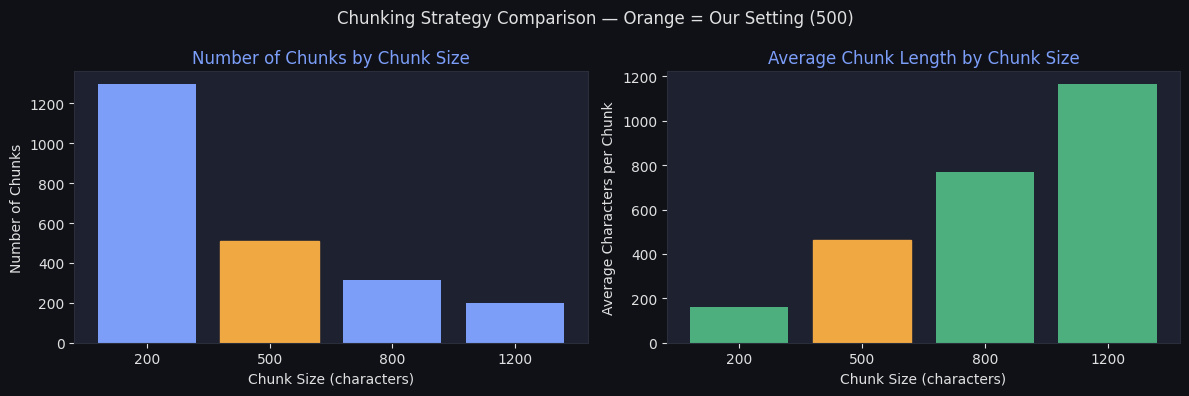

Saved: chunking_comparison.png


In [21]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
fig.patch.set_facecolor("#0f1117")

sizes    = [r["chunk_size"] for r in results]
n_chunks = [r["num_chunks"] for r in results]
avg_lens = [r["avg_len"]    for r in results]

for ax in [ax1, ax2]:
    ax.set_facecolor("#1e2130")
    ax.tick_params(colors="#e0e0e0")
    ax.xaxis.label.set_color("#e0e0e0")
    ax.yaxis.label.set_color("#e0e0e0")
    ax.title.set_color("#7c9ef8")
    for spine in ax.spines.values():
        spine.set_edgecolor("#2a2d3a")

bars1 = ax1.bar([str(s) for s in sizes], n_chunks, color="#7c9ef8")
bars1[1].set_color("#f0a843")   # highlight chunk_size=500
ax1.set_title("Number of Chunks by Chunk Size")
ax1.set_xlabel("Chunk Size (characters)")
ax1.set_ylabel("Number of Chunks")

bars2 = ax2.bar([str(s) for s in sizes], avg_lens, color="#4caf7d")
bars2[1].set_color("#f0a843")   # highlight chunk_size=500
ax2.set_title("Average Chunk Length by Chunk Size")
ax2.set_xlabel("Chunk Size (characters)")
ax2.set_ylabel("Average Characters per Chunk")

plt.suptitle("Chunking Strategy Comparison — Orange = Our Setting (500)", color="#e0e0e0", fontsize=12)
plt.tight_layout()
plt.savefig("chunking_comparison.png", dpi=150, bbox_inches="tight", facecolor="#0f1117")
plt.show()
print("Saved: chunking_comparison.png")

In [22]:
# Show sample chunks and verify overlap is working
current = results[1]   # chunk_size=500
print(f"chunk_size=500 | total chunks from this document: {current['num_chunks']}")
print()
print("=== Sample Chunk 1 ===")
print(current["chunks"][0])
print()
print("=== Sample Chunk 2 ===")
print(current["chunks"][1])
print()
print("=== Overlap check (last 100 chars of chunk 1 / first 100 chars of chunk 2) ===")
print("End of chunk 1 :", current["chunks"][0][-100:])
print("Start of chunk 2:", current["chunks"][1][:100])

chunk_size=500 | total chunks from this document: 509

=== Sample Chunk 1 ===
This text is meant purely as a documentation tool and has no legal effect. The Union's institutions do not assume any liability 
for its contents. The authentic versions of the relevant acts, including their preambles, are those published in the Official 
Journal of the European Union and available in EUR-Lex. Those official texts are directly accessible through the links 
embedded in this document 
►B REGULATION (EU) 2016/679 OF THE EUROPEAN PARLIAMENT AND OF THE COUNCIL 
of 27 April 2016

=== Sample Chunk 2 ===
►B REGULATION (EU) 2016/679 OF THE EUROPEAN PARLIAMENT AND OF THE COUNCIL 
of 27 April 2016 
on the protection of natural persons with regard to the processing of personal data and on the free 
movement of such data, and repealing Directive 95/46/EC (General Data Protection Regulation) 
(Text with EEA relevance) 
(OJ L 119, 4.5.2016, p. 1) 
Corrected by: 
►C1 
Corrigendum, OJ L 127, 23.5.2018, p. 2 (

## 2. Embedding Visualisation

We embed the first 100 chunks and use UMAP (or PCA as fallback) to reduce
384 dimensions to 2D so we can plot them.
Chunks about similar topics should cluster together in the plot.

Install UMAP if you want better results: `pip install umap-learn`

In [23]:
from sentence_transformers import SentenceTransformer

print("Loading embedding model: paraphrase-multilingual-MiniLM-L12-v2")
model  = SentenceTransformer("paraphrase-multilingual-MiniLM-L12-v2")
chunks = current["chunks"][:100]

print(f"Embedding {len(chunks)} chunks...")
embeddings = model.encode(chunks, show_progress_bar=True, convert_to_numpy=True)
print(f"Shape: {embeddings.shape}  (each chunk = {embeddings.shape[1]} numbers)")

Loading embedding model: paraphrase-multilingual-MiniLM-L12-v2
Embedding 100 chunks...


Batches: 100%|██████████| 4/4 [00:07<00:00,  1.96s/it]

Shape: (100, 384)  (each chunk = 384 numbers)


In [24]:
try:
    import umap
    reducer = umap.UMAP(n_components=2, random_state=42, n_neighbors=10)
    method  = "UMAP"
    print("Using UMAP")
except ImportError:
    from sklearn.decomposition import PCA
    reducer = PCA(n_components=2)
    method  = "PCA"
    print("umap-learn not installed, using PCA fallback")
    print("Install with: pip install umap-learn --break-system-packages")

print(f"Reducing {embeddings.shape[1]} dimensions to 2D with {method}...")
reduced = reducer.fit_transform(embeddings)
print(f"Done — reduced shape: {reduced.shape}")

umap-learn not installed, using PCA fallback
Install with: pip install umap-learn --break-system-packages
Reducing 384 dimensions to 2D with PCA...
Done — reduced shape: (100, 2)


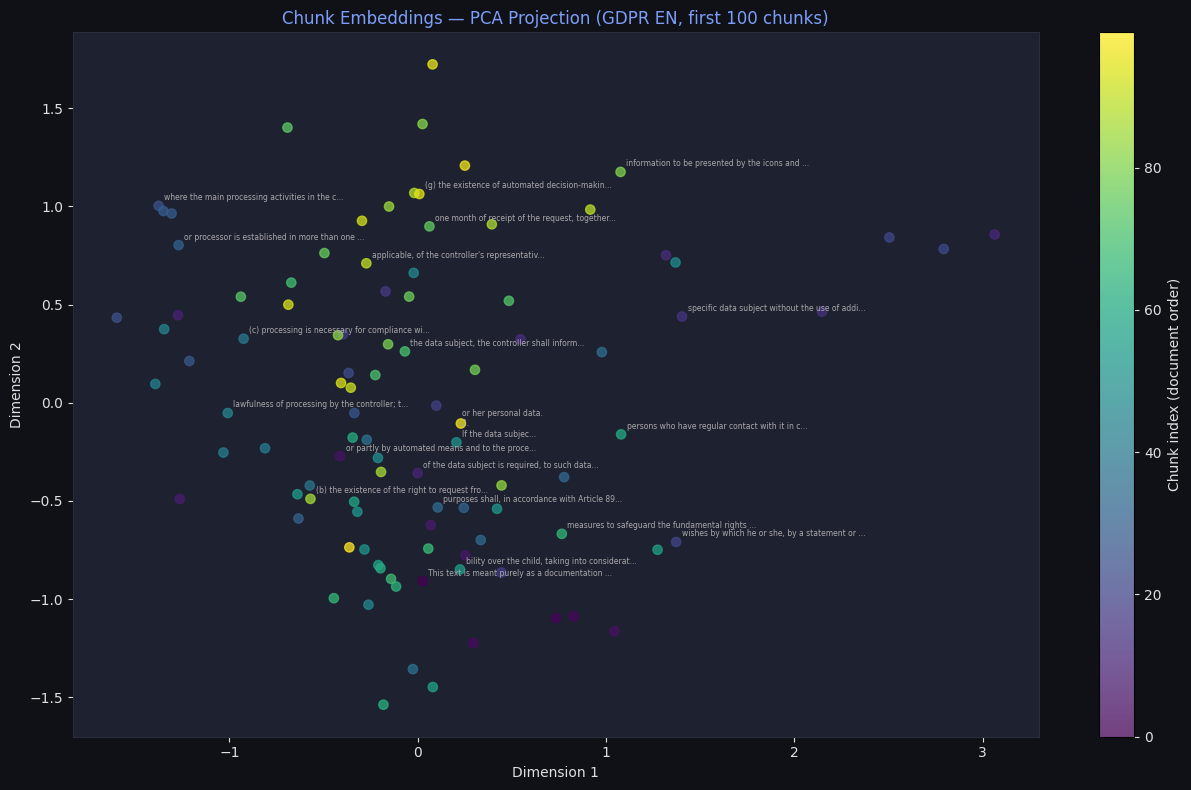

Saved: embedding_visualisation.png


In [25]:
fig, ax = plt.subplots(figsize=(13, 8))
fig.patch.set_facecolor("#0f1117")
ax.set_facecolor("#1e2130")

scatter = ax.scatter(
    reduced[:, 0],
    reduced[:, 1],
    c=range(len(chunks)),
    cmap="viridis",
    alpha=0.75,
    s=45,
)

# Label every 5th chunk with its first 45 characters
for i in range(0, len(chunks), 5):
    ax.annotate(
        chunks[i][:45] + "...",
        (reduced[i, 0], reduced[i, 1]),
        fontsize=5.5,
        color="#aaaaaa",
        xytext=(4, 4),
        textcoords="offset points",
    )

ax.set_title(f"Chunk Embeddings — {method} Projection (GDPR EN, first 100 chunks)", color="#7c9ef8", fontsize=12)
ax.set_xlabel("Dimension 1", color="#e0e0e0")
ax.set_ylabel("Dimension 2", color="#e0e0e0")
ax.tick_params(colors="#e0e0e0")
for spine in ax.spines.values():
    spine.set_edgecolor("#2a2d3a")

cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label("Chunk index (document order)", color="#e0e0e0")
cbar.ax.yaxis.set_tick_params(color="#e0e0e0")
plt.setp(cbar.ax.yaxis.get_ticklabels(), color="#e0e0e0")

plt.tight_layout()
plt.savefig("embedding_visualisation.png", dpi=150, bbox_inches="tight", facecolor="#0f1117")
plt.show()
print("Saved: embedding_visualisation.png")

## 3. Retrieval Quality Check

We run test queries against the live vector store and inspect:
- Which chunks come back
- What similarity scores they have
- Whether the sources are correct

Make sure the app has been run at least once and documents are ingested.

In [26]:
from src.components.embedding_engine import EmbeddingEngine
from src.components.retriever import Retriever

engine    = EmbeddingEngine()
retriever = Retriever(engine)

print(f"Total chunks in vector store : {engine.count()}")
print(f"Ingested documents           : {engine.list_documents()}")

2026-04-21 11:24:01 | INFO     | src.components.embedding_engine | embedding_engine.py:42 | Loading embedding model: paraphrase-multilingual-MiniLM-L12-v2
INFO:src.components.embedding_engine:Loading embedding model: paraphrase-multilingual-MiniLM-L12-v2
2026-04-21 11:24:04 | INFO     | src.components.embedding_engine | embedding_engine.py:49 | Connecting to ChromaDB at: D:\PaperMind\artifacts\vectorstore
INFO:src.components.embedding_engine:Connecting to ChromaDB at: D:\PaperMind\artifacts\vectorstore
ERROR:chromadb.telemetry.product.posthog:Failed to send telemetry event ClientStartEvent: capture() takes 1 positional argument but 3 were given
ERROR:chromadb.telemetry.product.posthog:Failed to send telemetry event ClientCreateCollectionEvent: capture() takes 1 positional argument but 3 were given
2026-04-21 11:24:04 | INFO     | src.components.embedding_engine | embedding_engine.py:62 | EmbeddingEngine ready — collection 'papermind_docs' has 6603 chunks
INFO:src.components.embedding_e

Total chunks in vector store : 6603


ERROR:chromadb.telemetry.product.posthog:Failed to send telemetry event CollectionGetEvent: capture() takes 1 positional argument but 3 were given


Ingested documents           : ['2510.11503v1.pdf', 'Bosch_Supplier_Manual.pdf', 'Devarshi_Dixit.pdf', 'GDPR_DE.pdf', 'GDPR_EN.pdf', 'VW_Annual_Report_2023.pdf', 'test.pdf']


In [27]:
# Test queries — covers all 4 demo documents and both languages
test_queries = [
    "What are the principles for processing personal data under GDPR?",
    "Was sind die Rechte der betroffenen Personen?",
    "What quality requirements does Bosch place on suppliers?",
    "What was the Volkswagen Group revenue in 2023?",
    "What is the maximum fine for GDPR violations?",
]

for query in test_queries:
    print(f"\nQuery: '{query}'")
    print("-" * 65)
    retrieved = retriever.retrieve(query, n_results=3)
    for i, chunk in enumerate(retrieved, 1):
        print(f"  [{i}] Score: {chunk.score:.4f} | {chunk.source} | Page {chunk.page}")
        print(f"       {chunk.text[:120]}...")
    print()

2026-04-21 11:24:04 | INFO     | src.components.retriever | retriever.py:47 | Retrieving top 3 chunks for query: 'What are the principles for processing personal data under GDPR?'
INFO:src.components.retriever:Retrieving top 3 chunks for query: 'What are the principles for processing personal data under GDPR?'
ERROR:chromadb.telemetry.product.posthog:Failed to send telemetry event CollectionQueryEvent: capture() takes 1 positional argument but 3 were given



Query: 'What are the principles for processing personal data under GDPR?'
-----------------------------------------------------------------


2026-04-21 11:24:05 | INFO     | src.components.embedding_engine | embedding_engine.py:158 | Query returned 3 chunks (top score: 0.631)
INFO:src.components.embedding_engine:Query returned 3 chunks (top score: 0.631)
2026-04-21 11:24:05 | INFO     | src.components.retriever | retriever.py:70 | Retrieved 3 chunks — top score: 0.6310 (Medium) from 'GDPR_EN.pdf' page 6
INFO:src.components.retriever:Retrieved 3 chunks — top score: 0.6310 (Medium) from 'GDPR_EN.pdf' page 6
2026-04-21 11:24:05 | INFO     | src.components.retriever | retriever.py:47 | Retrieving top 3 chunks for query: 'Was sind die Rechte der betroffenen Personen?'
INFO:src.components.retriever:Retrieving top 3 chunks for query: 'Was sind die Rechte der betroffenen Personen?'
2026-04-21 11:24:05 | INFO     | src.components.embedding_engine | embedding_engine.py:158 | Query returned 3 chunks (top score: 0.7502)
INFO:src.components.embedding_engine:Query returned 3 chunks (top score: 0.7502)
2026-04-21 11:24:05 | INFO     | src

  [1] Score: 0.6310 | GDPR_EN.pdf | Page 6
       CHAPTER II
Principles
Article 5
Principles relating to processing of personal data
1.
Personal data shall be:
(a) proces...
  [2] Score: 0.6172 | GDPR_DE.pdf | Page 4
       02016R0679 — DE — 04.05.2016 — 000.003 — 4
4. „Profiling“ jede Art der automatisierten Verarbeitung personenbe­
zogener ...
  [3] Score: 0.6022 | GDPR_EN.pdf | Page 9
       02016R0679 — EN — 04.05.2016 — 000.002 — 9
(b) the context in which the personal data have been collected, in
particular...


Query: 'Was sind die Rechte der betroffenen Personen?'
-----------------------------------------------------------------
  [1] Score: 0.7502 | GDPR_DE.pdf | Page 12
       Anwendung, es sei denn, die betroffene Person stellt zur Ausübung ihrer
in diesen Artikeln niedergelegten Rechte zusätzl...
  [2] Score: 0.7492 | GDPR_DE.pdf | Page 41
       setzbare Rechte der betroffenen Person und wirksame verwaltungs­
rechtliche und gerichtliche Rechtsbehelfe für betroffen...
  [3]

## 4. Similarity Score Distribution

We run 15 queries across all documents and plot the distribution of
cosine similarity scores for retrieved chunks.

This verifies that our confidence thresholds make sense:
- High   > 0.75
- Medium 0.50 – 0.75
- Low    < 0.50

In [28]:
import matplotlib.patches as mpatches

sample_queries = [
    "What is the purpose of GDPR?",
    "What are data subject rights?",
    "What is the maximum GDPR fine?",
    "What is a data protection impact assessment?",
    "What does Bosch require from suppliers?",
    "What are Bosch logistics requirements?",
    "What was Volkswagen revenue in 2023?",
    "How many vehicles did Volkswagen deliver?",
    "What is Volkswagen electric vehicle strategy?",
    "What are GDPR breach notification rules?",
    "Was sind personenbezogene Daten?",
    "Welche Pflichten hat der Verantwortliche?",
    "What is data minimisation?",
    "What is purpose limitation under GDPR?",
    "What is Bosch supplier quality management?",
]

all_scores = []
per_query_top = []

for q in sample_queries:
    try:
        retrieved = retriever.retrieve(q, n_results=5)
        scores    = [c.score for c in retrieved]
        all_scores.extend(scores)
        per_query_top.append(max(scores))
        print(f"  top={max(scores):.4f} | {q[:55]}")
    except Exception as e:
        print(f"  SKIP: {q[:55]} — {e}")

print(f"\nTotal scores collected : {len(all_scores)}")
print(f"Min  : {min(all_scores):.4f}")
print(f"Max  : {max(all_scores):.4f}")
print(f"Mean : {sum(all_scores)/len(all_scores):.4f}")

2026-04-21 11:24:05 | INFO     | src.components.retriever | retriever.py:47 | Retrieving top 5 chunks for query: 'What is the purpose of GDPR?'
INFO:src.components.retriever:Retrieving top 5 chunks for query: 'What is the purpose of GDPR?'
2026-04-21 11:24:05 | INFO     | src.components.embedding_engine | embedding_engine.py:158 | Query returned 5 chunks (top score: 0.541)
INFO:src.components.embedding_engine:Query returned 5 chunks (top score: 0.541)
2026-04-21 11:24:05 | INFO     | src.components.retriever | retriever.py:70 | Retrieved 5 chunks — top score: 0.5410 (Medium) from 'VW_Annual_Report_2023.pdf' page 209
INFO:src.components.retriever:Retrieved 5 chunks — top score: 0.5410 (Medium) from 'VW_Annual_Report_2023.pdf' page 209
2026-04-21 11:24:05 | INFO     | src.components.retriever | retriever.py:47 | Retrieving top 5 chunks for query: 'What are data subject rights?'
INFO:src.components.retriever:Retrieving top 5 chunks for query: 'What are data subject rights?'
2026-04-21 11:

  top=0.5410 | What is the purpose of GDPR?
  top=0.7778 | What are data subject rights?
  top=0.5535 | What is the maximum GDPR fine?
  top=0.8466 | What is a data protection impact assessment?


2026-04-21 11:24:05 | INFO     | src.components.embedding_engine | embedding_engine.py:158 | Query returned 5 chunks (top score: 0.7717)
INFO:src.components.embedding_engine:Query returned 5 chunks (top score: 0.7717)
2026-04-21 11:24:05 | INFO     | src.components.retriever | retriever.py:70 | Retrieved 5 chunks — top score: 0.7717 (High) from 'Bosch_Supplier_Manual.pdf' page 6
INFO:src.components.retriever:Retrieved 5 chunks — top score: 0.7717 (High) from 'Bosch_Supplier_Manual.pdf' page 6
2026-04-21 11:24:05 | INFO     | src.components.retriever | retriever.py:47 | Retrieving top 5 chunks for query: 'What are Bosch logistics requirements?'
INFO:src.components.retriever:Retrieving top 5 chunks for query: 'What are Bosch logistics requirements?'
2026-04-21 11:24:05 | INFO     | src.components.embedding_engine | embedding_engine.py:158 | Query returned 5 chunks (top score: 0.6681)
INFO:src.components.embedding_engine:Query returned 5 chunks (top score: 0.6681)
2026-04-21 11:24:05 | IN

  top=0.7717 | What does Bosch require from suppliers?
  top=0.6681 | What are Bosch logistics requirements?
  top=0.8159 | What was Volkswagen revenue in 2023?


2026-04-21 11:24:05 | INFO     | src.components.embedding_engine | embedding_engine.py:158 | Query returned 5 chunks (top score: 0.7788)
INFO:src.components.embedding_engine:Query returned 5 chunks (top score: 0.7788)
2026-04-21 11:24:05 | INFO     | src.components.retriever | retriever.py:70 | Retrieved 5 chunks — top score: 0.7788 (High) from 'VW_Annual_Report_2023.pdf' page 123
INFO:src.components.retriever:Retrieved 5 chunks — top score: 0.7788 (High) from 'VW_Annual_Report_2023.pdf' page 123
2026-04-21 11:24:05 | INFO     | src.components.retriever | retriever.py:47 | Retrieving top 5 chunks for query: 'What is Volkswagen electric vehicle strategy?'
INFO:src.components.retriever:Retrieving top 5 chunks for query: 'What is Volkswagen electric vehicle strategy?'
2026-04-21 11:24:05 | INFO     | src.components.embedding_engine | embedding_engine.py:158 | Query returned 5 chunks (top score: 0.7767)
INFO:src.components.embedding_engine:Query returned 5 chunks (top score: 0.7767)
2026-0

  top=0.7788 | How many vehicles did Volkswagen deliver?
  top=0.7767 | What is Volkswagen electric vehicle strategy?
  top=0.6478 | What are GDPR breach notification rules?


2026-04-21 11:24:06 | INFO     | src.components.embedding_engine | embedding_engine.py:158 | Query returned 5 chunks (top score: 0.8013)
INFO:src.components.embedding_engine:Query returned 5 chunks (top score: 0.8013)
2026-04-21 11:24:06 | INFO     | src.components.retriever | retriever.py:70 | Retrieved 5 chunks — top score: 0.8013 (High) from 'GDPR_DE.pdf' page 4
INFO:src.components.retriever:Retrieved 5 chunks — top score: 0.8013 (High) from 'GDPR_DE.pdf' page 4
2026-04-21 11:24:06 | INFO     | src.components.retriever | retriever.py:47 | Retrieving top 5 chunks for query: 'Welche Pflichten hat der Verantwortliche?'
INFO:src.components.retriever:Retrieving top 5 chunks for query: 'Welche Pflichten hat der Verantwortliche?'
2026-04-21 11:24:06 | INFO     | src.components.embedding_engine | embedding_engine.py:158 | Query returned 5 chunks (top score: 0.7759)
INFO:src.components.embedding_engine:Query returned 5 chunks (top score: 0.7759)
2026-04-21 11:24:06 | INFO     | src.component

  top=0.8013 | Was sind personenbezogene Daten?
  top=0.7759 | Welche Pflichten hat der Verantwortliche?
  top=0.7252 | What is data minimisation?
  top=0.5814 | What is purpose limitation under GDPR?


2026-04-21 11:24:06 | INFO     | src.components.embedding_engine | embedding_engine.py:158 | Query returned 5 chunks (top score: 0.7291)
INFO:src.components.embedding_engine:Query returned 5 chunks (top score: 0.7291)
2026-04-21 11:24:06 | INFO     | src.components.retriever | retriever.py:70 | Retrieved 5 chunks — top score: 0.7291 (Medium) from 'Bosch_Supplier_Manual.pdf' page 6
INFO:src.components.retriever:Retrieved 5 chunks — top score: 0.7291 (Medium) from 'Bosch_Supplier_Manual.pdf' page 6


  top=0.7291 | What is Bosch supplier quality management?

Total scores collected : 75
Min  : 0.4551
Max  : 0.8466
Mean : 0.6585


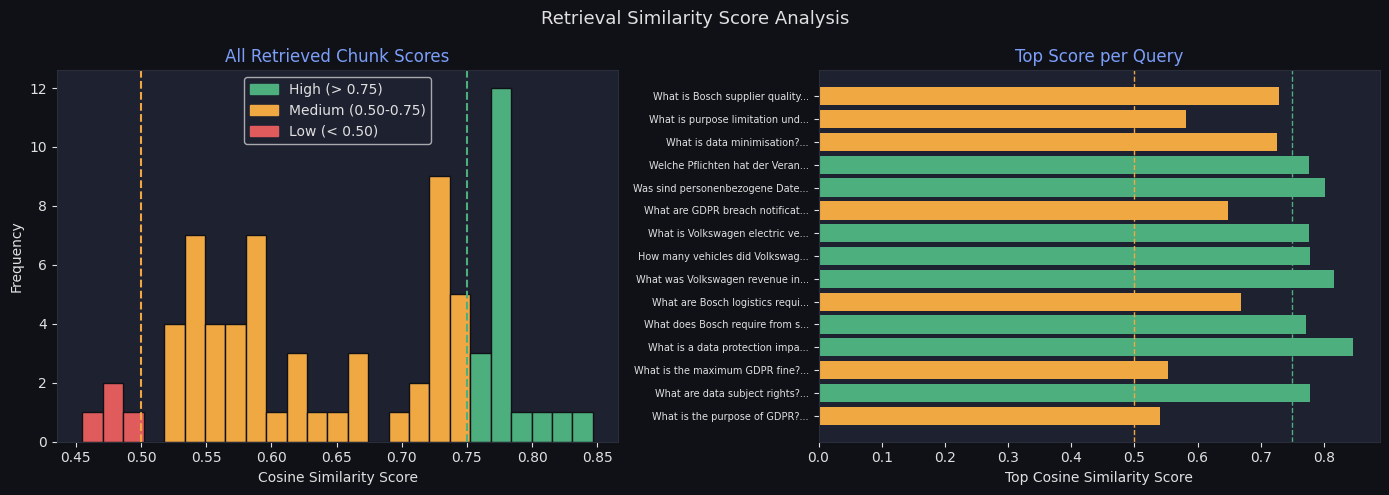

Saved: score_distribution.png


In [29]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor("#0f1117")

for ax in [ax1, ax2]:
    ax.set_facecolor("#1e2130")
    ax.tick_params(colors="#e0e0e0")
    ax.xaxis.label.set_color("#e0e0e0")
    ax.yaxis.label.set_color("#e0e0e0")
    ax.title.set_color("#7c9ef8")
    for spine in ax.spines.values():
        spine.set_edgecolor("#2a2d3a")

# Left plot — full score distribution
n, bins, patches = ax1.hist(all_scores, bins=25, edgecolor="#0f1117")
for patch, left_edge in zip(patches, bins[:-1]):
    if left_edge >= 0.75:
        patch.set_facecolor("#4caf7d")
    elif left_edge >= 0.50:
        patch.set_facecolor("#f0a843")
    else:
        patch.set_facecolor("#e05c5c")

ax1.axvline(0.75, color="#4caf7d", linestyle="--", linewidth=1.5)
ax1.axvline(0.50, color="#f0a843", linestyle="--", linewidth=1.5)
ax1.set_title("All Retrieved Chunk Scores")
ax1.set_xlabel("Cosine Similarity Score")
ax1.set_ylabel("Frequency")

high_p   = mpatches.Patch(color="#4caf7d", label="High (> 0.75)")
medium_p = mpatches.Patch(color="#f0a843", label="Medium (0.50-0.75)")
low_p    = mpatches.Patch(color="#e05c5c", label="Low (< 0.50)")
ax1.legend(handles=[high_p, medium_p, low_p], facecolor="#1e2130", labelcolor="#e0e0e0")

# Right plot — top score per query
colors = ["#4caf7d" if s >= 0.75 else "#f0a843" if s >= 0.50 else "#e05c5c" for s in per_query_top]
short_queries = [q[:30] + "..." for q in sample_queries[:len(per_query_top)]]
bars = ax2.barh(range(len(per_query_top)), per_query_top, color=colors)
ax2.set_yticks(range(len(per_query_top)))
ax2.set_yticklabels(short_queries, fontsize=7)
ax2.axvline(0.75, color="#4caf7d", linestyle="--", linewidth=1)
ax2.axvline(0.50, color="#f0a843", linestyle="--", linewidth=1)
ax2.set_title("Top Score per Query")
ax2.set_xlabel("Top Cosine Similarity Score")
ax2.tick_params(axis="y", colors="#e0e0e0")

plt.suptitle("Retrieval Similarity Score Analysis", color="#e0e0e0", fontsize=13)
plt.tight_layout()
plt.savefig("score_distribution.png", dpi=150, bbox_inches="tight", facecolor="#0f1117")
plt.show()
print("Saved: score_distribution.png")

## 5. Evaluation Results Summary

These are the scores from our custom embedding-based evaluation
run on 25 manually created QA pairs across all 4 demo documents.

In [30]:
import json

results_path = "../artifacts/evaluation_results.json"

with open(results_path) as f:
    scores = json.load(f)

metrics = {
    "Answer Relevancy":  scores.get("answer_relevancy",  "N/A"),
    "Faithfulness":      scores.get("faithfulness",      "N/A"),
    "Context Precision": scores.get("context_precision", "N/A"),
    "Context Recall":    scores.get("context_recall",    "N/A"),
}

print("=" * 45)
print("  PaperMind Evaluation Results")
print("=" * 45)
for metric, score in metrics.items():
    bar_len = int(float(score) * 30) if isinstance(score, float) else 0
    bar     = "#" * bar_len + "-" * (30 - bar_len)
    print(f"  {metric:<22} {score:.4f}  [{bar}]")
print(f"  Pairs evaluated       {scores.get('num_evaluated', 'N/A')}")
print("=" * 45)

  PaperMind Evaluation Results
  Answer Relevancy       0.7636  [######################--------]
  Faithfulness           0.8824  [##########################----]
  Context Precision      1.0000  [##############################]
  Context Recall         0.8800  [##########################----]
  Pairs evaluated       25


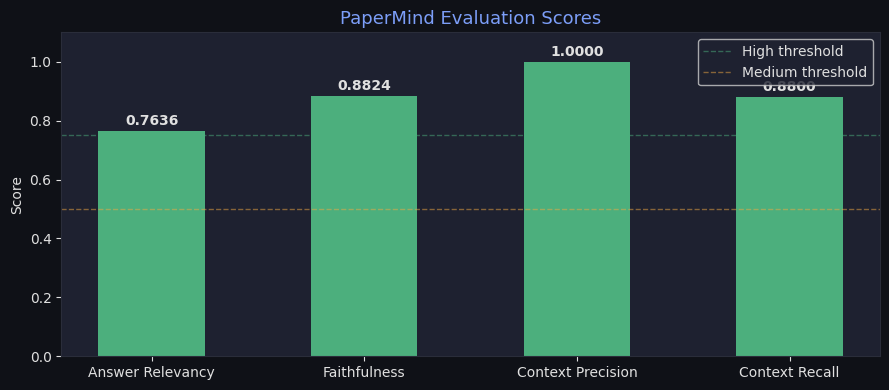

Saved: evaluation_results.png


In [31]:
fig, ax = plt.subplots(figsize=(9, 4))
fig.patch.set_facecolor("#0f1117")
ax.set_facecolor("#1e2130")

metric_names  = list(metrics.keys())
metric_values = [float(v) for v in metrics.values()]
colors        = ["#4caf7d" if v >= 0.75 else "#f0a843" if v >= 0.50 else "#e05c5c" for v in metric_values]

bars = ax.bar(metric_names, metric_values, color=colors, width=0.5)

# Add value labels on top of bars
for bar, val in zip(bars, metric_values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.01,
        f"{val:.4f}",
        ha="center",
        va="bottom",
        color="#e0e0e0",
        fontsize=10,
        fontweight="bold",
    )

ax.set_ylim(0, 1.1)
ax.axhline(0.75, color="#4caf7d", linestyle="--", linewidth=1, alpha=0.5, label="High threshold")
ax.axhline(0.50, color="#f0a843", linestyle="--", linewidth=1, alpha=0.5, label="Medium threshold")
ax.set_title("PaperMind Evaluation Scores", color="#7c9ef8", fontsize=13)
ax.set_ylabel("Score", color="#e0e0e0")
ax.tick_params(colors="#e0e0e0")
ax.legend(facecolor="#1e2130", labelcolor="#e0e0e0")
for spine in ax.spines.values():
    spine.set_edgecolor("#2a2d3a")

plt.tight_layout()
plt.savefig("evaluation_results.png", dpi=150, bbox_inches="tight", facecolor="#0f1117")
plt.show()
print("Saved: evaluation_results.png")